In [21]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import cv2
import tensorflow as tf
#Image Processing
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Machine learning utilities
from sklearn.model_selection import train_test_split
#Deep Learning
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, MaxPooling2D,
    BatchNormalization, Activation, concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
from google.colab import drive
drive.mount('/content/drive')

images = np.load("/content/drive/MyDrive/BRAIN MRI TUMOR/archive/images.npy")
masks  = np.load("/content/drive/MyDrive/BRAIN MRI TUMOR/archive/masks.npy")

Mounted at /content/drive


In [3]:
input_dir = '/content/drive/MyDrive/BRAIN MRI TUMOR/archive/kaggle_3m'
#output_images = '/content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/images'
#output_masks = '/content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/masks'

#os.makedirs(output_images, exist_ok=True)
#os.makedirs(output_masks, exist_ok=True)

# lables each image with its corresponding maks images



In [4]:
data = []
for folder in os.listdir(input_dir):
    #print(folder)
    folder_path = os.path.join(input_dir, folder)
    if os.path.isdir(folder_path):
      for file in os.listdir(folder_path):
        #print(file)
        if file.endswith('.tif') and not '_mask' in file:
            image_path = os.path.join(folder_path, file)
            mask_file = file.replace('.tif', '_mask.tif')
            mask_path = os.path.join(folder_path, mask_file)
            if os.path.exists(mask_path):
                data.append({
                    'image_path': image_path,
                    'mask_path': mask_path,
                    'image_name' : os.path.basename(image_path),
                    'mask_name' : os.path.basename(mask_path)
                })
brain_df = pd.DataFrame(data);
brain_df.head()

,image_path,mask_path,image_name,mask_name
0,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,TCGA_HT_A616_19991226_2.tif,TCGA_HT_A616_19991226_2_mask.tif
1,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,TCGA_HT_A616_19991226_21.tif,TCGA_HT_A616_19991226_21_mask.tif
2,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,TCGA_HT_A616_19991226_13.tif,TCGA_HT_A616_19991226_13_mask.tif
3,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,TCGA_HT_A616_19991226_14.tif,TCGA_HT_A616_19991226_14_mask.tif
4,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,/content/drive/MyDrive/BRAIN MRI TUMOR/archive...,TCGA_HT_A616_19991226_23.tif,TCGA_HT_A616_19991226_23_mask.tif


In [ ]:
tumor_status = []

for mask_path in tqdm.tqdm(brain_df["mask_path"], desc="Checking masks"):
    mask = img_to_array(load_img(mask_path, color_mode="grayscale"))
    if np.max(mask) > 0:
        tumor_status.append("Tumor")
    else:
        tumor_status.append("Non-Tumor")

brain_df["status"] = tumor_status
brain_df.head()

In [ ]:
counts = brain_df["status"].value_counts()
print(counts)

In [ ]:
plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values, color=["red", "gray"])
plt.title("Tumor vs Non-Tumor Image Count", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.bar_label(bars, padding=3)
plt.show()

2.2 Preprocessing

In [5]:
IMG_SIZE = 64

def process_image(image_path, mask_path, img_size=IMG_SIZE):
    # Load image
    image = load_img(image_path, target_size=(img_size, img_size))
    image = img_to_array(image) / 255.0  # Normalize

    # Load mask (grayscale)
    mask = load_img(mask_path, target_size=(img_size, img_size), color_mode="grayscale")
    mask = img_to_array(mask)

    # Ensure mask is binary (0 or 1)
    mask = mask / 255.0
    mask = np.where(mask > 0.5, 1, 0)

    return image.astype(np.float32), mask.astype(np.float32)

In [6]:
from concurrent.futures import ThreadPoolExecutor
import numpy as np
#import multiprocessing
#cpu_cores = multiprocessing.cpu_count()
#print("CPU cores:", cpu_cores)

def load_pair(paths):
    return process_image(*paths)

paths = list(zip(brain_df['image_path'], brain_df['mask_path']))

with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(load_pair, paths))

images, masks = zip(*results)
images = np.array(images)
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

KeyboardInterrupt: 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (3143, 128, 128, 3) (3143, 128, 128, 1)
Test:  (786, 128, 128, 3) (786, 128, 128, 1)


In [4]:
def visualize_samples(images, masks, n_samples=4):
    """
    Show random tumor and non-tumor MRI images with their masks.
    """
    tumor_indices = []
    non_tumor_indices = []

    # Separate indices for tumor and non-tumor
    for i in range(len(masks)):
        if np.max(masks[i]) > 0:      # Tumor present
            tumor_indices.append(i)
        else:                         # No tumor
            non_tumor_indices.append(i)



    # Choose random samples
    tumor_samples = random.sample(tumor_indices, min(n_samples, len(tumor_indices)))
    non_tumor_samples = random.sample(non_tumor_indices, min(n_samples, len(non_tumor_indices)))

    # Plot
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(tumor_samples):
        plt.subplot(2, n_samples, i+1)
        plt.imshow(images[idx])
        plt.imshow(masks[idx].squeeze(), cmap="Reds", alpha=0.4)
        plt.title("Tumor")
        plt.axis("off")

    for i, idx in enumerate(non_tumor_samples):
        plt.subplot(2, n_samples, i + 1 + n_samples)
        plt.imshow(images[idx])
        plt.imshow(masks[idx].squeeze(), cmap="Reds", alpha=0.3)
        plt.title("No Tumor")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

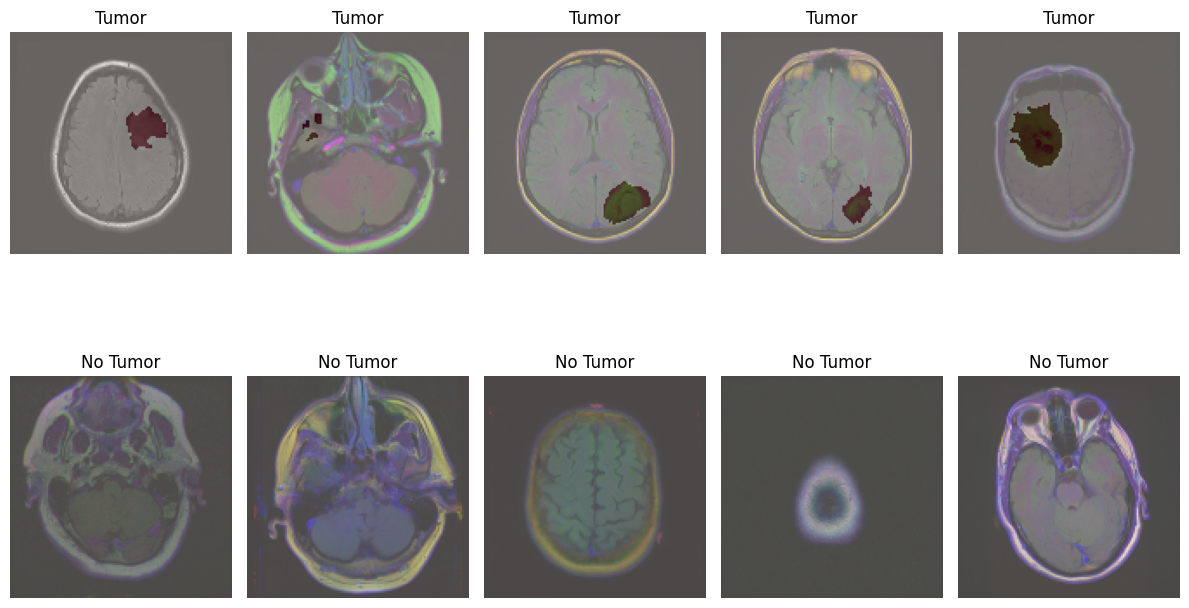

In [5]:
visualize_samples(X_test, y_test, n_samples=5)

In [6]:
# Augmentation configurations
data_gen_args = dict(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create ImageDataGenerator for both images and masks
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# Same seed to ensure images and masks are augmented equally
seed = 42
batch_size = 4

image_generator = image_datagen.flow(X_train, batch_size=batch_size, seed=seed)
mask_generator = mask_datagen.flow(y_train, batch_size=batch_size, seed=seed)

In [7]:
def train_gen(image_gen, mask_gen):
    while True:
        img_batch = next(image_gen)
        mask_batch = next(mask_gen)

        yield (img_batch, mask_batch)

train_generator = train_gen(image_generator, mask_generator)


Model Definition

U-Net Architecture

In [9]:
IMG_SIZE = 128
def conv_block(x, filters, kernel_size=3, batch_norm=True, dropout=0.0):
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    if dropout and dropout > 0.0:
        x = layers.Dropout(dropout)(x)
    return x

def encoder_block(x, filters, pool=True, pool_size=(2,2), dropout=0.0):
    c = conv_block(x, filters, dropout=dropout)
    if pool:
        p = layers.MaxPooling2D(pool_size)(c)
        return c, p
    else:
        return c

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, (2,2), strides=(2,2), padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), out_channels=1, base_filters=32, dropout_rate=0.1):
    inputs = layers.Input(shape=input_shape)
    # Encoder
    c1, p1 = encoder_block(inputs, base_filters, pool=True, dropout=dropout_rate)      # 32
    c2, p2 = encoder_block(p1, base_filters*2, pool=True, dropout=dropout_rate)        # 64
    c3, p3 = encoder_block(p2, base_filters*4, pool=True, dropout=dropout_rate)        # 128
    c4, p4 = encoder_block(p3, base_filters*8, pool=True, dropout=dropout_rate)        # 256

    # Bottleneck
    b = conv_block(p4, base_filters*16, batch_norm=True, dropout=dropout_rate)         # 512

    # Decoder
    d1 = decoder_block(b, c4, base_filters*8)
    d2 = decoder_block(d1, c3, base_filters*4)
    d3 = decoder_block(d2, c2, base_filters*2)
    d4 = decoder_block(d3, c1, base_filters)

    # Output
    if out_channels == 1:
        outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(d4)
    else:
        outputs = layers.Conv2D(out_channels, (1,1), activation='softmax')(d4)

    model = Model(inputs, outputs, name='UNet_Professional')
    return model


model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), out_channels=1, base_filters=32, dropout_rate=0.1)
model.summary()


Model: "UNet_Professional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ dropout_1[0][0] 

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [10]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dl = dice_loss(y_true, y_pred)
    return bce + dl

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    total = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    union = total - intersection
    return (intersection + smooth) / (union + smooth)


3.2 Compile Model

In [11]:
#  Compile Model
LEARNING_RATE = 1e-4
model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
              loss=bce_dice_loss,
              metrics=[dice_coef, iou_coef, 'accuracy'])

In [12]:
#  Callbacks
checkpoint_path = "/content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/checkpoints/unet_best.h5"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

Model Trianing

In [13]:
#  Train Model with Augmentation
steps_per_epoch = len(X_train) // batch_size

history = model.fit(
    train_generator,
    validation_data=(X_test, y_test),
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
784/785 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9561 - dice_coef: 0.0606 - iou_coef: 0.0327 - loss: 1.2111
Epoch 1: val_loss improved from inf to 0.94361, saving model to /content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/checkpoints/unet_best.h5


785/785 ━━━━━━━━━━━━━━━━━━━━ 52s 30ms/step - accuracy: 0.9561 - dice_coef: 0.0607 - iou_coef: 0.0328 - loss: 1.2108 - val_accuracy: 0.9889 - val_dice_coef: 0.1472 - val_iou_coef: 0.0800 - val_loss: 0.9436 - learning_rate: 1.0000e-04
Epoch 2/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9872 - dice_coef: 0.1780 - iou_coef: 0.1080 - loss: 0.8932
Epoch 2: val_loss improved from 0.94361 to 0.78432, saving model to /content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/checkpoints/unet_best.h5


785/785 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.9872 - dice_coef: 0.1781 - iou_coef: 0.1080 - loss: 0.8931 - val_accuracy: 0.9915 - val_dice_coef: 0.2568 - val_iou_coef: 0.1498 - val_loss: 0.7843 - learning_rate: 1.0000e-04
Epoch 3/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9888 - dice_coef: 0.3174 - iou_coef: 0.2167 - loss: 0.7252
Epoch 3: val_loss improved from 0.78432 to 0.60024, saving model to /content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/checkpoints/unet_best.h5


785/785 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9888 - dice_coef: 0.3174 - iou_coef: 0.2168 - loss: 0.7251 - val_accuracy: 0.9926 - val_dice_coef: 0.4373 - val_iou_coef: 0.2822 - val_loss: 0.6002 - learning_rate: 1.0000e-04
Epoch 4/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9895 - dice_coef: 0.4011 - iou_coef: 0.2938 - loss: 0.6365
Epoch 4: val_loss improved from 0.60024 to 0.49154, saving model to /content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/checkpoints/unet_best.h5


785/785 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9895 - dice_coef: 0.4012 - iou_coef: 0.2939 - loss: 0.6365 - val_accuracy: 0.9925 - val_dice_coef: 0.5477 - val_iou_coef: 0.3804 - val_loss: 0.4915 - learning_rate: 1.0000e-04
Epoch 5/20
784/785 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9905 - dice_coef: 0.4537 - iou_coef: 0.3464 - loss: 0.5806
Epoch 5: val_loss improved from 0.49154 to 0.42599, saving model to /content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/checkpoints/unet_best.h5


785/785 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9905 - dice_coef: 0.4538 - iou_coef: 0.3464 - loss: 0.5806 - val_accuracy: 0.9932 - val_dice_coef: 0.6112 - val_iou_coef: 0.4453 - val_loss: 0.4260 - learning_rate: 1.0000e-04
Epoch 6/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9907 - dice_coef: 0.4758 - iou_coef: 0.3708 - loss: 0.5596
Epoch 6: val_loss did not improve from 0.42599
785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9907 - dice_coef: 0.4758 - iou_coef: 0.3708 - loss: 0.5596 - val_accuracy: 0.9927 - val_dice_coef: 0.6049 - val_iou_coef: 0.4380 - val_loss: 0.4340 - learning_rate: 1.0000e-04
Epoch 7/20
783/785 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9908 - dice_coef: 0.4941 - iou_coef: 0.3870 - loss: 0.5420
Epoch 7: val_loss improved from 0.42599 to 0.40730, saving model to /content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/checkpoints/unet_best.h5


785/785 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.9908 - dice_coef: 0.4940 - iou_coef: 0.3870 - loss: 0.5421 - val_accuracy: 0.9932 - val_dice_coef: 0.6312 - val_iou_coef: 0.4684 - val_loss: 0.4073 - learning_rate: 1.0000e-04
Epoch 8/20
784/785 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9914 - dice_coef: 0.4768 - iou_coef: 0.3777 - loss: 0.5560
Epoch 8: val_loss did not improve from 0.40730
785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9914 - dice_coef: 0.4768 - iou_coef: 0.3777 - loss: 0.5559 - val_accuracy: 0.9935 - val_dice_coef: 0.6228 - val_iou_coef: 0.4584 - val_loss: 0.4163 - learning_rate: 1.0000e-04
Epoch 9/20
783/785 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9917 - dice_coef: 0.5109 - iou_coef: 0.4058 - loss: 0.5210
Epoch 9: val_loss did not improve from 0.40730
785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9917 - dice_coef: 0.5109 - iou_coef: 0.4058 - loss: 0.5210 - val_accuracy: 0.9923 - val_dice_coef: 0.6297 - val_iou_coef: 0.4664 - 

785/785 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9923 - dice_coef: 0.5431 - iou_coef: 0.4431 - loss: 0.4927 - val_accuracy: 0.9932 - val_dice_coef: 0.6483 - val_iou_coef: 0.4885 - val_loss: 0.3981 - learning_rate: 5.0000e-05
Epoch 13/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9925 - dice_coef: 0.5342 - iou_coef: 0.4405 - loss: 0.5007
Epoch 13: val_loss improved from 0.39813 to 0.39518, saving model to /content/drive/MyDrive/BRAIN MRI TUMOR/archive/working/checkpoints/unet_best.h5


785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9925 - dice_coef: 0.5342 - iou_coef: 0.4405 - loss: 0.5007 - val_accuracy: 0.9935 - val_dice_coef: 0.6512 - val_iou_coef: 0.4900 - val_loss: 0.3952 - learning_rate: 5.0000e-05
Epoch 14/20
783/785 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9927 - dice_coef: 0.5742 - iou_coef: 0.4822 - loss: 0.4630
Epoch 14: val_loss did not improve from 0.39518
785/785 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9927 - dice_coef: 0.5742 - iou_coef: 0.4822 - loss: 0.4629 - val_accuracy: 0.9934 - val_dice_coef: 0.6166 - val_iou_coef: 0.4516 - val_loss: 0.4394 - learning_rate: 5.0000e-05
Epoch 15/20
784/785 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9925 - dice_coef: 0.5997 - iou_coef: 0.5048 - loss: 0.4386
Epoch 15: val_loss did not improve from 0.39518
785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9925 - dice_coef: 0.5997 - iou_coef: 0.5048 - loss: 0.4386 - val_accuracy: 0.9937 - val_dice_coef: 0.6198 - val_iou_coef: 0.454

785/785 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9922 - dice_coef: 0.6082 - iou_coef: 0.5176 - loss: 0.4364 - val_accuracy: 0.9934 - val_dice_coef: 0.6546 - val_iou_coef: 0.4952 - val_loss: 0.3945 - learning_rate: 5.0000e-05
Epoch 17/20
783/785 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9922 - dice_coef: 0.5934 - iou_coef: 0.4998 - loss: 0.4436
Epoch 17: val_loss did not improve from 0.39445
785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9922 - dice_coef: 0.5935 - iou_coef: 0.4999 - loss: 0.4435 - val_accuracy: 0.9939 - val_dice_coef: 0.6548 - val_iou_coef: 0.4958 - val_loss: 0.3950 - learning_rate: 5.0000e-05
Epoch 18/20
784/785 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9925 - dice_coef: 0.6419 - iou_coef: 0.5417 - loss: 0.3953
Epoch 18: val_loss did not improve from 0.39445
785/785 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9925 - dice_coef: 0.6419 - iou_coef: 0.5416 - loss: 0.3954 - val_accuracy: 0.9933 - val_dice_coef: 0.5995 - val_iou_coef: 0.434

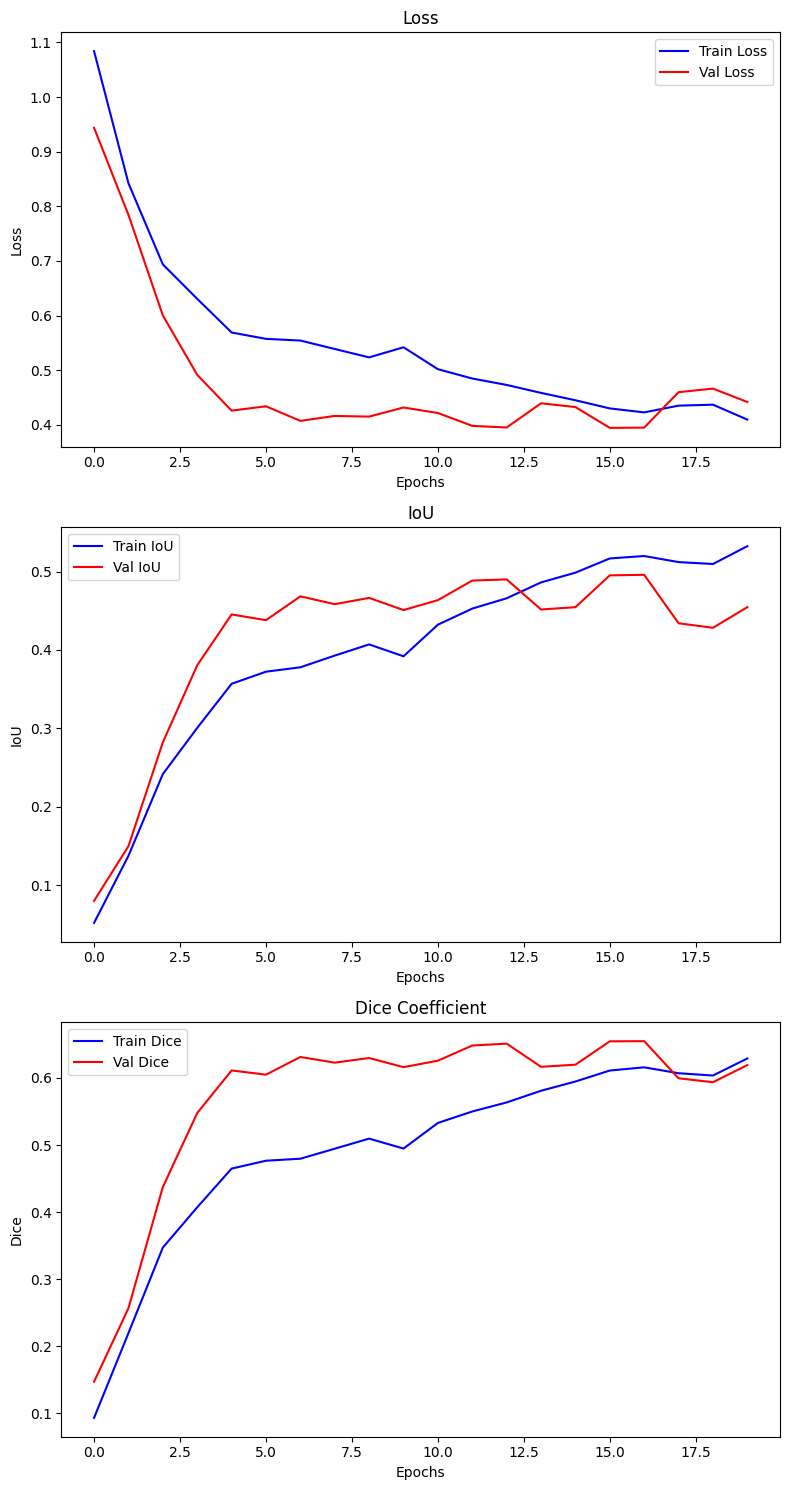

In [14]:
# Evaluation Visualization
plt.figure(figsize=(8, 15))

# --- Loss ---
plt.subplot(3, 1, 1)
plt.plot(history.history['loss'], 'b-', label='Train Loss')
plt.plot(history.history['val_loss'], 'r-', label='Val Loss')
plt.legend(loc='best')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# --- IoU ---
plt.subplot(3, 1, 2)
plt.plot(history.history['iou_coef'], 'b-', label='Train IoU')
plt.plot(history.history['val_iou_coef'], 'r-', label='Val IoU')
plt.legend(loc='best')
plt.title('IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')

# --- Dice Coefficient ---
plt.subplot(3, 1, 3)
plt.plot(history.history['dice_coef'], 'b-', label='Train Dice')
plt.plot(history.history['val_dice_coef'], 'r-', label='Val Dice')
plt.legend(loc='best')
plt.title('Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice')

plt.tight_layout()
plt.show()

In [16]:
#Model Evaluation

BATCH_SIZE=4
# Define test data generator (no augmentation)
test_datagen = ImageDataGenerator()

# Create generator for test data
test_generator = test_datagen.flow(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Evaluate model
results = model.evaluate(test_generator, steps=len(X_test) // BATCH_SIZE)

print(f" Test Loss: {results[0]:.4f}")
print(f" Test Dice Coefficient: {results[1]:.4f}")
print(f" Test IoU: {results[2]:.4f}")
print(f" Test Accuracy: {results[3]:.4f}")

196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9937 - dice_coef: 0.6277 - iou_coef: 0.5386 - loss: 0.4172
 Test Loss: 0.4548
 Test Dice Coefficient: 0.5940
 Test IoU: 0.5007
 Test Accuracy: 0.9934


Tumuour Presence Detection

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


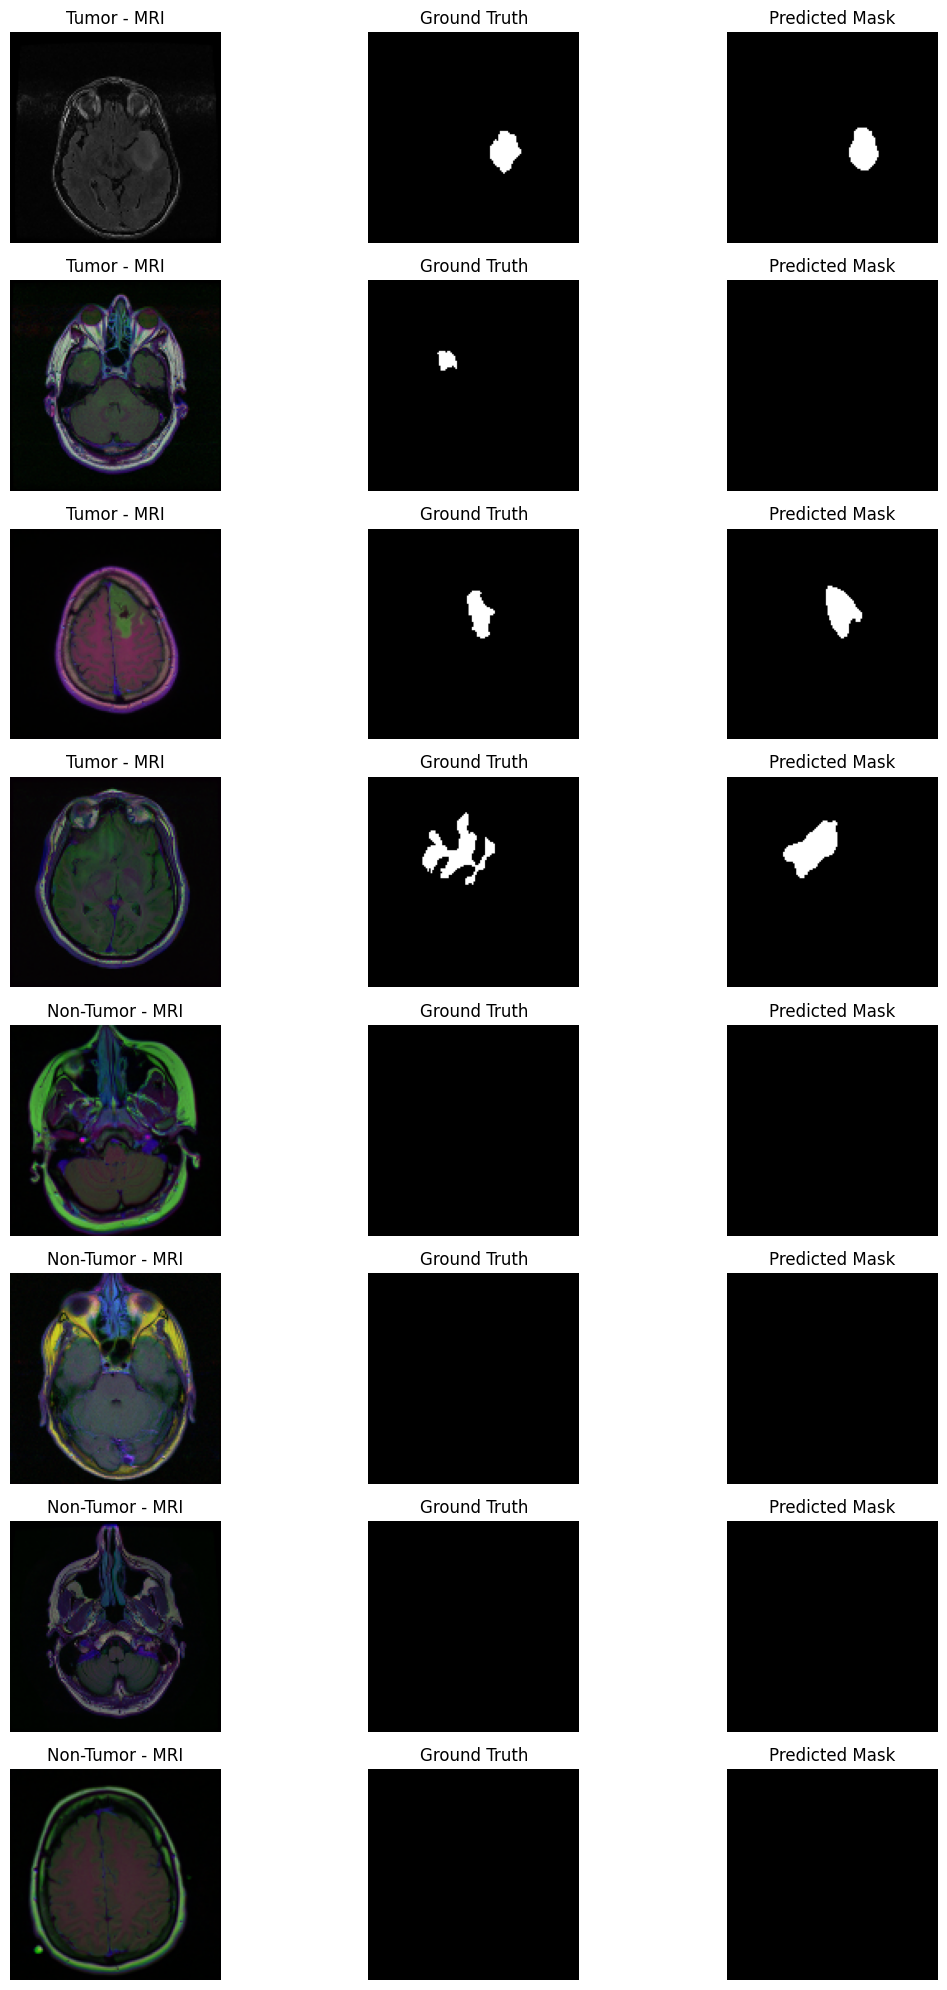

In [17]:
def visualize_predictions(model, X_test, y_test, num_per_class=4):
    """
    Visualize a balanced set of tumor and non-tumor samples with
    original MRI, ground truth mask, and predicted mask.
    """
    # Flatten masks to detect presence of tumor (any pixel > 0)
    tumor_indices = [i for i in range(len(y_test)) if np.any(y_test[i] > 0)]
    non_tumor_indices = [i for i in range(len(y_test)) if not np.any(y_test[i] > 0)]

    # Ensure enough samples exist in both categories
    tumor_indices = random.sample(tumor_indices, min(num_per_class, len(tumor_indices)))
    non_tumor_indices = random.sample(non_tumor_indices, min(num_per_class, len(non_tumor_indices)))

    selected_indices = tumor_indices + non_tumor_indices
    total_samples = len(selected_indices)

    plt.figure(figsize=(12, total_samples * 2.5))

    for i, idx in enumerate(selected_indices):
        image = X_test[idx]
        true_mask = y_test[idx]

        # Predict mask
        pred_mask = model.predict(np.expand_dims(image, axis=0))[0]
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

        # Titles
        label = "Tumor" if np.any(true_mask > 0) else "Non-Tumor"

        # Original MRI
        plt.subplot(total_samples, 3, i*3 + 1)
        plt.imshow(image)
        plt.title(f"{label} - MRI")
        plt.axis("off")

        # Ground truth mask
        plt.subplot(total_samples, 3, i*3 + 2)
        plt.imshow(true_mask.squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        # Predicted mask
        plt.subplot(total_samples, 3, i*3 + 3)
        plt.imshow(pred_mask.squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
# Run visualization
visualize_predictions(model, X_test, y_test, num_per_class=4)

### 7.1 Evaluate Tumor Detection Accuracy

In [18]:
from tqdm import tqdm

correct, incorrect = 0, 0

# Loop through test set
for i in tqdm(range(len(X_test)), desc="Evaluating tumor detection"):
    # Get image and true mask
    img = np.expand_dims(X_test[i], axis=0)
    true_mask = y_test[i].squeeze()

    # Predict mask
    pred = model.predict(img, verbose=0)
    pred_mask = np.squeeze(pred) > 0.5

    # Check if both masks indicate tumor presence
    has_tumor_true = true_mask.any()
    has_tumor_pred = pred_mask.any()

    # Compare prediction
    is_correct = has_tumor_true == has_tumor_pred
    print(f"Prediction {i}: {' Correct' if is_correct else ' Incorrect'}")

    if is_correct:
        correct += 1
    else:
        incorrect += 1

# Final accuracy for tumor presence detection
accuracy = correct / (correct + incorrect)
print("\n Tumor Presence Detection Summary")
print(f"✔ Correct: {correct}")
print(f"✖ Incorrect: {incorrect}")
print(f" Accuracy: {accuracy * 100:.2f}%")

Evaluating tumor detection:   0%|          | 2/786 [00:00<00:56, 13.87it/s]

Prediction 0:  Correct
Prediction 1:  Correct
Prediction 2:  Correct


Evaluating tumor detection:   1%|          | 6/786 [00:00<00:52, 14.74it/s]

Prediction 3:  Correct
Prediction 4:  Correct
Prediction 5:  Correct
Prediction 6:  Correct


Evaluating tumor detection:   1%|▏         | 10/786 [00:00<00:53, 14.61it/s]

...

Prediction 778:  Correct
Prediction 779:  Incorrect
Prediction 780:  Incorrect


Evaluating tumor detection: 100%|█████████▉| 784/786 [00:55<00:00, 14.33it/s]

Prediction 781:  Correct
Prediction 782:  Incorrect
Prediction 783:  Correct


Evaluating tumor detection: 100%|██████████| 786/786 [00:55<00:00, 14.09it/s]

Prediction 784:  Correct
Prediction 785:  Correct

 Tumor Presence Detection Summary
✔ Correct: 682
✖ Incorrect: 104
 Accuracy: 86.77%


## 8. Visualization of Predictions

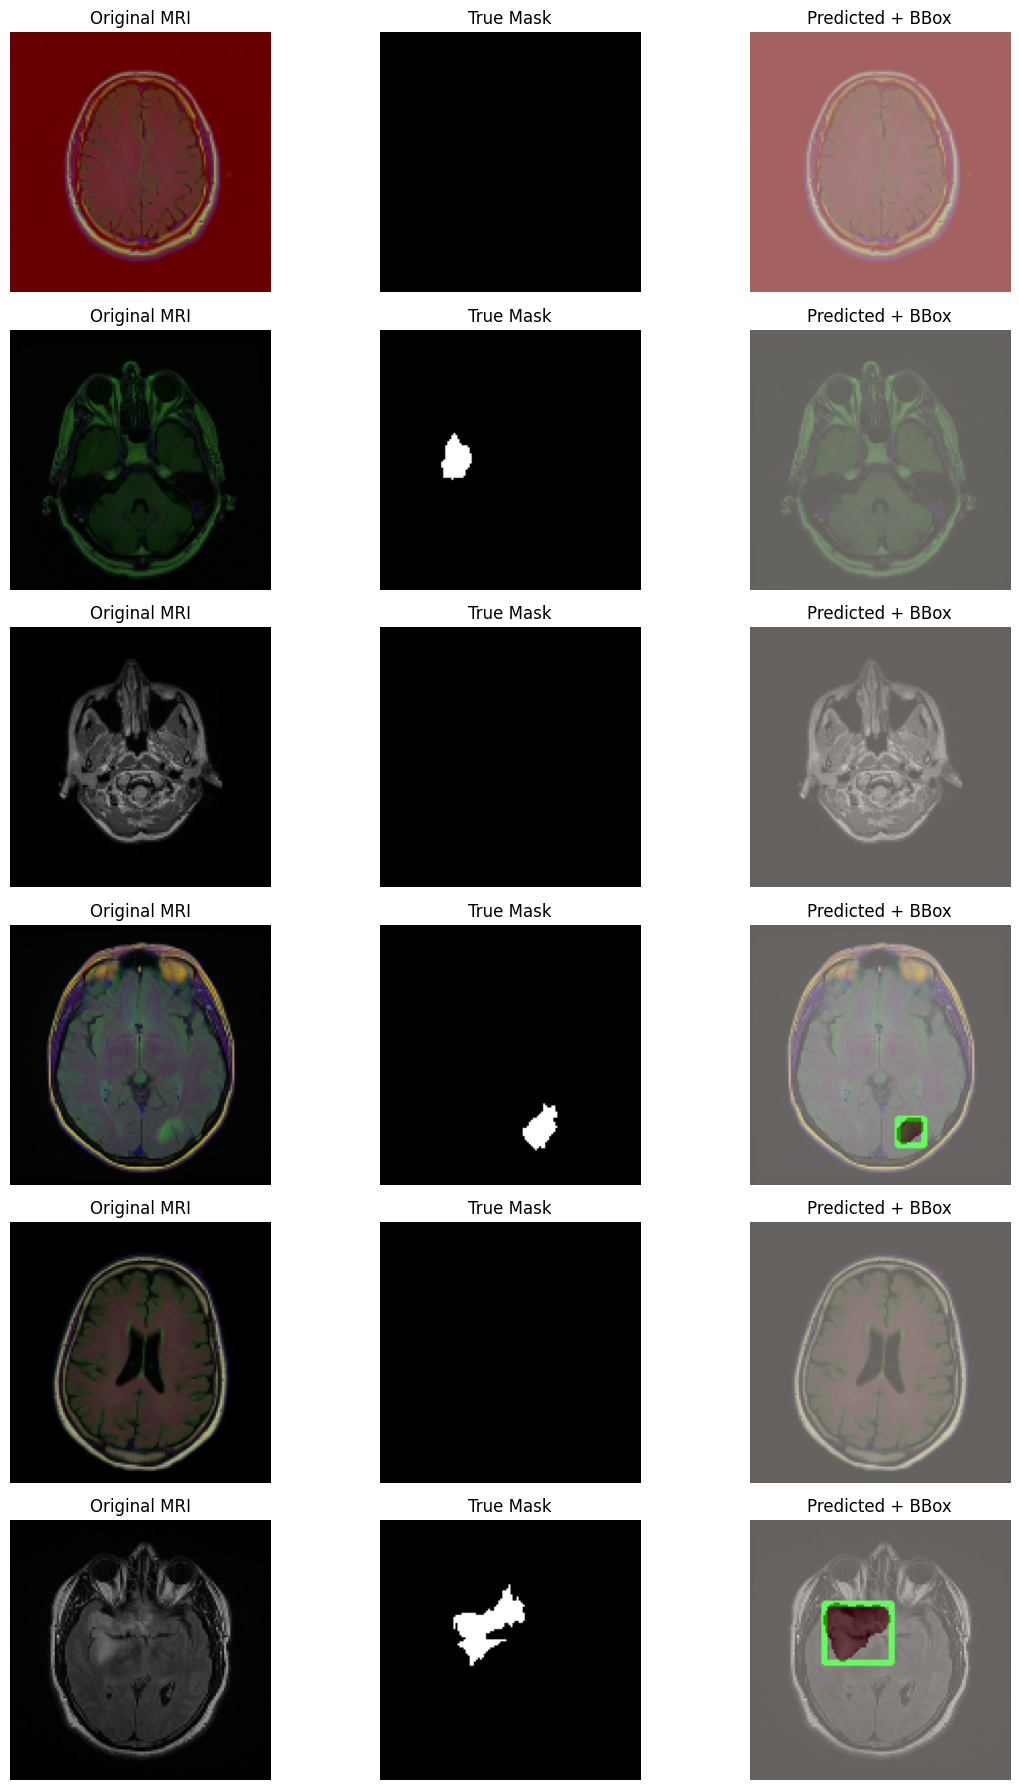

In [22]:
def visualize_with_bbox(model, X_test, y_test, num_samples=5, threshold=0.5):
    """
    Visualize predicted masks and bounding boxes for tumor regions.
    """
    indices = random.sample(range(len(X_test)), num_samples)
    plt.figure(figsize=(12, num_samples * 3))

    for i, idx in enumerate(indices):
        # Get image and true mask
        image = (X_test[idx] * 255).astype(np.uint8)
        true_mask = (y_test[idx].squeeze() * 255).astype(np.uint8)

        # Predict mask
        pred = model.predict(np.expand_dims(X_test[idx], axis=0), verbose=0)[0]
        pred_mask = (pred.squeeze() > threshold).astype(np.uint8) * 255

        # Find contours on predicted mask
        contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        image_with_bbox = image.copy()

        # Draw bounding boxes
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(image_with_bbox, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Show image + mask + bbox
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(image)
        plt.title("Original MRI")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(image_with_bbox)
        plt.imshow(pred_mask, cmap="Reds", alpha=0.4)
        plt.title("Predicted + BBox")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Run visualization
visualize_with_bbox(model, X_test, y_test, num_samples=6)